<a href="https://colab.research.google.com/github/Ewanjohndennis/ML_LAB/blob/main/assignment4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Problem Statement
A teacher collected data from previous students regarding the number of hours they studied before an examination and whether they passed the exam.

Using the given dataset:
1. **Read the dataset.**
2. **Train a Logistic Regression model** using **Gradient Descent** *(do not use high-level ML libraries like `scikit-learn`)*.
3. **Calculate the model accuracy.**
4. **Predict** whether a student studying **4.5 hours**, **6 hours**, and **9 hours** is likely to pass.
5. **Plot the data points** along with the fitted logistic regression curve.

---

## Dataset

> **Note:** Students can either type this data directly into Python or save it as `student_pass.csv`.

| Hours Studied | Pass (Target) |
| :---: | :---: |
| 1.0 | 0 |
| 1.5 | 0 |
| 2.0 | 0 |
| 2.5 | 0 |
| 3.0 | 0 |
| 3.5 | 0 |
| 4.0 | 0 |
| 4.5 | 1 |
| 5.0 | 1 |
| 5.5 | 1 |
| 6.0 | 1 |
| 6.5 | 1 |
| 7.0 | 1 |
| 7.5 | 1 |
| 8.0 | 1 |
| 8.5 | 1 |
| 9.0 | 1 |
| 9.5 | 1 |
| 10.0 | 1 |
| 10.5 | 1 |

    Hours Studied  Pass
0             1.0     0
1             1.5     0
2             2.0     0
3             2.5     0
4             3.0     0
5             3.5     0
6             4.0     0
7             4.5     1
8             5.0     1
9             5.5     1
10            6.0     1
11            6.5     1
12            7.0     1
13            7.5     1
14            8.0     1
15            8.5     1
16            9.0     1
17            9.5     1
18           10.0     1
19           10.5     1
Accuracy = 1.0
4.5 hours -> Probability = 0.652, Prediction = Pass
6.0 hours -> Probability = 0.993, Prediction = Pass
9.0 hours -> Probability = 1.000, Prediction = Pass


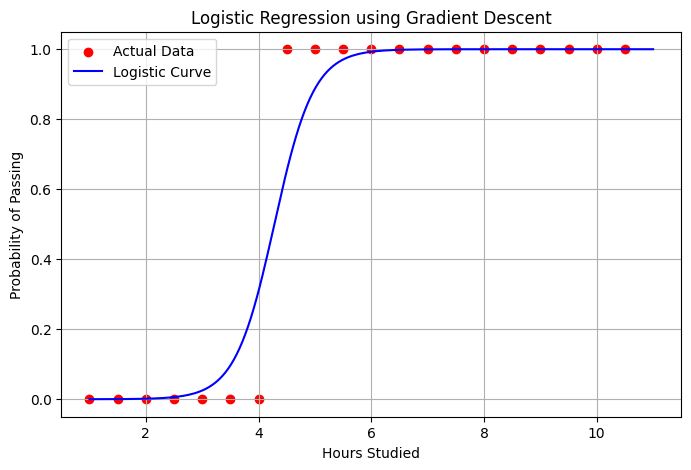

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Dataset
hours = np.array([1.0,1.5,2.0,2.5,3.0,3.5,4.0,4.5,5.0,5.5,
                  6.0,6.5,7.0,7.5,8.0,8.5,9.0,9.5,10.0,10.5])

passed = np.array([0,0,0,0,0,0,0,1,1,1,
                   1,1,1,1,1,1,1,1,1,1])

df = pd.DataFrame({
    "Hours Studied": hours,
    "Pass": passed
})

print(df)

X = hours.reshape(-1,1)
y = passed

# Normalize feature
X = (X - X.mean()) / X.std()

# Parameters
w = 0
b = 0
lr = 0.1
epochs = 5000

def sigmoid(z):
    return 1/(1+np.exp(-z))

m = len(y)

# Gradient Descent
for i in range(epochs):
    z = w*X.flatten() + b
    y_pred = sigmoid(z)

    dw = (1/m) * np.dot((y_pred-y), X.flatten())
    db = (1/m) * np.sum(y_pred-y)

    w -= lr*dw
    b -= lr*db

# Prediction
pred = sigmoid(w*X.flatten()+b)
pred_class = (pred>=0.5).astype(int)

accuracy = np.mean(pred_class==y)

print("Accuracy =", accuracy)

# Predict new values
new_hours = np.array([4.5,6,9]).reshape(-1,1)
new_scaled = (new_hours-hours.mean())/hours.std()

prob = sigmoid(w*new_scaled+b)

for h,p in zip(new_hours.flatten(),prob):
    print(f"{h} hours -> Probability = {p[0]:.3f}, Prediction = {'Pass' if p>=0.5 else 'Fail'}")

# Plot
x_vals = np.linspace(1,11,200)
x_scaled = (x_vals-hours.mean())/hours.std()
y_curve = sigmoid(w*x_scaled+b)

plt.figure(figsize=(8,5))
plt.scatter(hours,passed,color='red',label='Actual Data')
plt.plot(x_vals,y_curve,color='blue',label='Logistic Curve')
plt.xlabel("Hours Studied")
plt.ylabel("Probability of Passing")
plt.title("Logistic Regression using Gradient Descent")
plt.grid(True)
plt.legend()
plt.show()

##2. Problem Overview
A hospital has collected several diagnostic measurements from breast cancer patients. Each record contains features extracted from cell nuclei images. The target variable indicates whether the tumor is:

* `0` → **Malignant**
* `1` → **Benign**

Build a Logistic Regression model to classify tumors and evaluate its performance using different metrics.

---

## Dataset

Use the built-in dataset available in **Scikit-Learn**:

```python
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()
```

### Dataset Information
* **Number of samples:** 569
* **Number of features:** 30
* **Number of classes:** 2
* **Target names:**
  * Malignant (`0`)
  * Benign (`1`)

---

## Tasks

### Part A – Load and Explore the Dataset
1. Load the Breast Cancer dataset.
2. Convert it into a Pandas DataFrame.
3. Display:
   * First five rows
   * Dataset shape
   * Column names
   * Data types
   * Number of missing values
   * Class distribution

### Part B – Data Preprocessing
1. Separate the independent variables ($X$) and target ($y$).
2. Split the dataset into **80% training** and **20% testing**.
3. Standardize the feature values using `StandardScaler`.

### Part C – Build the Logistic Regression Model
1. Train a Logistic Regression classifier.
2. Predict the labels of the test dataset.
3. Predict the class probabilities using `predict_proba()`.

### Part D – Evaluate the Model
1. Calculate the following performance metrics:
   * Accuracy
   * Precision
   * Recall
   * F1-score
   * Confusion Matrix
   * Classification Report
2. Display the confusion matrix as a heatmap.

### Part E – ROC Curve
1. Compute the ROC Curve.
2. Calculate the Area Under Curve (AUC).
3. Plot the ROC curve.
4. Interpret the result.

### Part F – Probability Prediction
Predict the probability that the following patient has a malignant tumor:

```python
sample = X_test.iloc[0:1]
```

---

## Additional Exercises

1. Change the test size from 20% to 30%. Compare the evaluation metrics.
2. Train the model without feature scaling. Compare the accuracy with the scaled version.
3. Change the random state from 42 to 10 and observe the change in performance.
4. Print the coefficients of the Logistic Regression model and identify the five most influential features.
5. Predict the diagnosis for the first five test samples using `predict()` and `predict_proba()`.
6. Change the classification threshold from 0.5 to 0.7 and observe how precision and recall change.

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

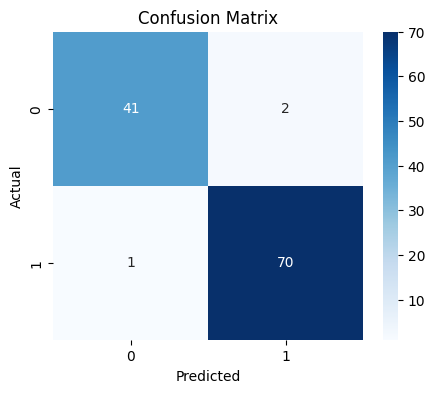

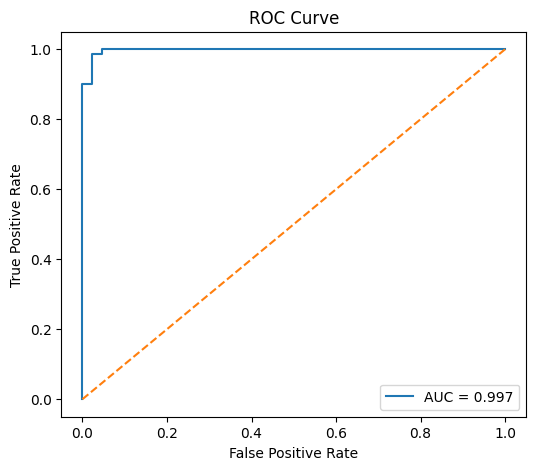

AUC = 0.99737962659679
Prediction: [1]
Probability: [[0.11359025 0.88640975]]

--- Test Size 30% ---
Accuracy: 0.9824561403508771

--- Without Scaling ---
Accuracy: 0.956140350877193

--- Random State = 10 ---
Accuracy: 0.9649122807017544

Top 5 Important Features
radius error           1.312251
worst texture          1.195759
compactness error      1.084334
worst radius           0.960136
mean concave points    0.921715
dtype: float64

First Five Predictions
[0 1 1 0 1]
[[9.92462276e-01 7.53772399e-03]
 [1.35933936e-05 9.99986407e-01]
 [1.51489203e-03 9.98485108e-01]
 [9.99927598e-01 7.24022180e-05]
 [1.03790768e-03 9.98962092e-01]]

Threshold = 0.7
Precision: 0.9722222222222222
Recall: 0.9333333333333333


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve
from sklearn.metrics import auc

# Load Dataset
data = load_breast_cancer()

df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

print(df.head())
print("\nShape:", df.shape)
print("\nColumns:", df.columns)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nClass Distribution:\n", df['target'].value_counts())

# Split
X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

# Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model
model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled,y_train)

# Prediction
y_pred = model.predict(X_test_scaled)

prob = model.predict_proba(X_test_scaled)

# Metrics
print("Accuracy :",accuracy_score(y_test,y_pred))
print("Precision :",precision_score(y_test,y_pred))
print("Recall :",recall_score(y_test,y_pred))
print("F1 Score :",f1_score(y_test,y_pred))

cm = confusion_matrix(y_test,y_pred)

print(cm)

print(classification_report(y_test,y_pred))

# Heatmap
plt.figure(figsize=(5,4))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# ROC
fpr,tpr,threshold=roc_curve(y_test,prob[:,1])

roc_auc=auc(fpr,tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr,tpr,label="AUC = %.3f"%roc_auc)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("AUC =",roc_auc)

sample = X_test.iloc[0:1]

sample_scaled = scaler.transform(sample)

prediction = model.predict(sample_scaled)

probability = model.predict_proba(sample_scaled)

print("Prediction:",prediction)
print("Probability:",probability)

# Additional Exercises

print("\n--- Test Size 30% ---")

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.3,random_state=42
)

X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

model.fit(X_train_scaled,y_train)

pred=model.predict(X_test_scaled)

print("Accuracy:",accuracy_score(y_test,pred))

print("\n--- Without Scaling ---")

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)

model.fit(X_train,y_train)

pred=model.predict(X_test)

print("Accuracy:",accuracy_score(y_test,pred))

print("\n--- Random State = 10 ---")

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=10
)

X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

model.fit(X_train_scaled,y_train)

pred=model.predict(X_test_scaled)

print("Accuracy:",accuracy_score(y_test,pred))

print("\nTop 5 Important Features")

coef=pd.Series(model.coef_[0],index=X.columns)

print(coef.abs().sort_values(ascending=False).head())

print("\nFirst Five Predictions")

print(model.predict(X_test_scaled[:5]))

print(model.predict_proba(X_test_scaled[:5]))

print("\nThreshold = 0.7")

prob=model.predict_proba(X_test_scaled)[:,1]

pred=(prob>=0.7).astype(int)

print("Precision:",precision_score(y_test,pred))
print("Recall:",recall_score(y_test,pred))

# 3. Problem Statement

Implement a logistic regression model to predict the likelihood of a disease using the Pima Indians Diabetes dataset. Compare the performance with and without feature scaling.

**Tasks:**

* Load and preprocess the Pima Indians Diabetes dataset.
* Implement logistic regression for binary classification.
* Evaluate model performance with and without feature scaling.
* Analyze metrics such as accuracy, precision, recall, and F1-score.

In [ ]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

# Load Dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

columns = [
    "Pregnancies","Glucose","BloodPressure","SkinThickness",
    "Insulin","BMI","DiabetesPedigreeFunction","Age","Outcome"
]

df = pd.read_csv(url, names=columns)

print(df.head())

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

# Without Scaling
model = LogisticRegression(max_iter=1000)

model.fit(X_train,y_train)

pred = model.predict(X_test)

print("WITHOUT SCALING")

print("Accuracy :",accuracy_score(y_test,pred))
print("Precision :",precision_score(y_test,pred))
print("Recall :",recall_score(y_test,pred))
print("F1 :",f1_score(y_test,pred))

# With Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model.fit(X_train_scaled,y_train)

pred_scaled = model.predict(X_test_scaled)

print("\nWITH SCALING")

print("Accuracy :",accuracy_score(y_test,pred_scaled))
print("Precision :",precision_score(y_test,pred_scaled))
print("Recall :",recall_score(y_test,pred_scaled))
print("F1 :",f1_score(y_test,pred_scaled))

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
WITHOUT SCALING
Accuracy : 0.7467532467532467
Precision : 0.6379310344827587
Recall : 0.6727272727272727
F1 : 0.6548672566371682

WITH SCALING
Accuracy : 0.7532467532467533
Precision : 0.6491228070175439
Recall : 0.6727272727272727
F1 : 0.6607142857142857
